In [39]:
from pygeoinf.symmetric_space.circle import Lebesgue
from pygeoinf.gaussian_measure import GaussianMeasure
import matplotlib.pyplot as plt

In [40]:
kmax = 100
M = Lebesgue(kmax)
measure = M.heat_kernel_gaussian_measure(0.1)

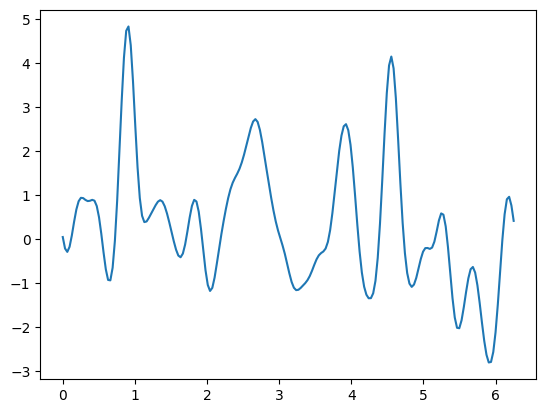

In [37]:
plt.plot(M.points(), measure.sample())

In [41]:
p = 0.95

ball = measure.credible_set(
    p,
    geometry="ambient_ball",
    spectrum=measure.spectral_variances,
    radius_method="spectral",
)

print(ball.radius)

5.173628710931141


Target mass p: 0.950
Ambient-ball radius: 5.173629
Empirical 95% norm quantile: 5.174738
Empirical mass inside ball: 0.949800


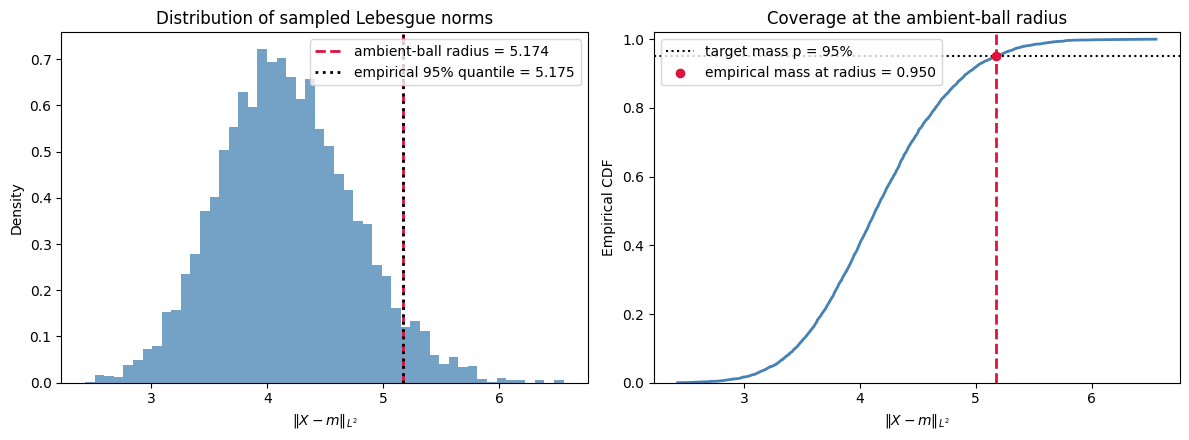

In [42]:
import numpy as np

n_samples = 5000
samples = measure.samples(n_samples)
norms = np.array([M.norm(M.subtract(sample, ball.center)) for sample in samples])
inside = np.array([ball.is_element(sample) for sample in samples])

empirical_radius = np.quantile(norms, p)
empirical_coverage = inside.mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(norms, bins=50, density=True, alpha=0.75, color="steelblue")
axes[0].axvline(
    ball.radius,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"ambient-ball radius = {ball.radius:.3f}",
)
axes[0].axvline(
    empirical_radius,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"empirical {p:.0%} quantile = {empirical_radius:.3f}",
)
axes[0].set_xlabel(r"$\|X-m\|_{L^2}$")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of sampled Lebesgue norms")
axes[0].legend()

sorted_norms = np.sort(norms)
cdf = np.arange(1, n_samples + 1) / n_samples
axes[1].plot(sorted_norms, cdf, color="steelblue", linewidth=2)
axes[1].axvline(ball.radius, color="crimson", linestyle="--", linewidth=2)
axes[1].axhline(
    p,
    color="black",
    linestyle=":",
    linewidth=1.5,
    label=f"target mass p = {p:.0%}",
)
axes[1].scatter(
    [ball.radius],
    [empirical_coverage],
    color="crimson",
    zorder=3,
    label=f"empirical mass at radius = {empirical_coverage:.3f}",
)
axes[1].set_xlabel(r"$\|X-m\|_{L^2}$")
axes[1].set_ylabel("Empirical CDF")
axes[1].set_title("Coverage at the ambient-ball radius")
axes[1].set_ylim(0.0, 1.02)
axes[1].legend()

plt.tight_layout()

print(f"Target mass p: {p:.3f}")
print(f"Ambient-ball radius: {ball.radius:.6f}")
print(f"Empirical {p:.0%} norm quantile: {empirical_radius:.6f}")
print(f"Empirical mass inside ball: {empirical_coverage:.6f}")